We want to identify a perturbation that 

1) Has very distinct effects in Basal and Multiciliated cells. These are at opposite ends of teh lineage spectrum for airway epithelium. 
2) Has reasonable test predictive accuracy in scLEMBAS.

In [2]:
import os
from contextlib import contextmanager
import warnings
from collections import defaultdict
import joblib

import pandas as pd
import numpy as np
from scipy.spatial.distance import cosine, euclidean

import torch

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns

import sys
sys.path.insert(1, '../../.')
from McCauley_utils import all_data, initialize_mod_and_trainer

sys.path.insert(1, '../../../.') 
from notebook_utils import get_split, clear_adata

sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS import latent_separation as ls
from scLEMBAS.predict import get_prediction

In [3]:
seed = 888
data_path = '/home/hmbaghda/orcd/pool/scLEMBAS/analysis'
author = 'McCauley'

n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(1)
os.environ["MKL_NUM_THREADS"] = str(1)
os.environ["OPENBLAS_NUM_THREADS"] = str(1)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(1)
os.environ["NUMEXPR_NUM_THREADS"] = str(1)

In [4]:
(sn_ppis, tf_adata, adata, expr, source_label, target_label, weight_label, 
 stimulation_label, inhibition_label, cat_col, pert_col, ctrl_pert) = all_data


In [19]:
# cell_types = ['Club', 'Multiciliated']
cell_types = ['Basal', 'Club']
pert = 'TGFB1' 

# Identify Distinct Perturbation Responses between Club and Goblet Cells

We will do this either by:

1) Strong cosine distances (different directions of perturbation)
2) Large magnitude differenes in expression shift

We will exclude perturbations in which either cell ttype as under 75 cells. 

In [9]:
def _to_dense(X):
    return X.toarray() if hasattr(X, "toarray") else np.asarray(X)

def _get_rep(adata, use_pls=False, pls_key='X_pls'):
    if use_pls:
        if pls_key not in adata.obsm:
            raise ValueError(f"{pls_key} not found in adata.obsm")
        return _to_dense(adata.obsm[pls_key])
    return _to_dense(adata.X)

def _centroid(adata, mask, use_pls=False, pls_key='X_pls'):
    X = _get_rep(adata, use_pls=use_pls, pls_key=pls_key)
    return X[np.asarray(mask)].mean(axis=0)

def _get_pert(adata):
    perts = [p for p in adata.obs[pert_col].unique() if p != ctrl_pert]
    if len(perts) != 1:
        raise ValueError(f"Expected exactly 1 perturbation besides {ctrl_pert}, found: {perts}")
    return perts[0]

def get_euclidean_distance(adata, use_pls=False, pls_key='X_pls'):
    pert = _get_pert(adata)
    cell_types = adata.obs[cat_col].unique()
    
    ed = {}
    for ct in cell_types:
        ctrl_mask = (adata.obs[cat_col] == ct) & (adata.obs[pert_col] == ctrl_pert)
        pert_mask = (adata.obs[cat_col] == ct) & (adata.obs[pert_col] == pert)
        
        mu_ctrl = _centroid(adata, ctrl_mask, use_pls=use_pls, pls_key=pls_key)
        mu_pert = _centroid(adata, pert_mask, use_pls=use_pls, pls_key=pls_key)
        
        ed[ct] = float(euclidean(mu_ctrl, mu_pert))
    
    return ed

def get_cosine_distance(adata, use_pls=False, pls_key='X_pls'):
    pert = _get_pert(adata)
    cell_types = list(adata.obs[cat_col].unique())
    if len(cell_types) != 2:
        raise ValueError(f"Expected exactly 2 cell types, found: {cell_types}")
    
    ct1, ct2 = cell_types
    
    ctrl_mask = adata.obs[pert_col] == ctrl_pert
    mu_ctrl = _centroid(adata, ctrl_mask, use_pls=use_pls, pls_key=pls_key)
    
    mu1_pert = _centroid(
        adata,
        (adata.obs[cat_col] == ct1) & (adata.obs[pert_col] == pert),
        use_pls=use_pls,
        pls_key=pls_key
    )
    mu2_pert = _centroid(
        adata,
        (adata.obs[cat_col] == ct2) & (adata.obs[pert_col] == pert),
        use_pls=use_pls,
        pls_key=pls_key
    )
    
    vec1 = mu1_pert - mu_ctrl
    vec2 = mu2_pert - mu_ctrl
    
    return float(cosine(vec1, vec2))

def get_convergence_label(adata, use_pls=False, pls_key='X_pls'):
    pert = _get_pert(adata)
    cell_types = list(adata.obs[cat_col].unique())
    if len(cell_types) != 2:
        raise ValueError(f"Expected exactly 2 cell types, found: {cell_types}")
    
    ct1, ct2 = cell_types
    
    mu1_ctrl = _centroid(
        adata,
        (adata.obs[cat_col] == ct1) & (adata.obs[pert_col] == ctrl_pert),
        use_pls=use_pls,
        pls_key=pls_key
    )
    mu2_ctrl = _centroid(
        adata,
        (adata.obs[cat_col] == ct2) & (adata.obs[pert_col] == ctrl_pert),
        use_pls=use_pls,
        pls_key=pls_key
    )
    mu1_pert = _centroid(
        adata,
        (adata.obs[cat_col] == ct1) & (adata.obs[pert_col] == pert),
        use_pls=use_pls,
        pls_key=pls_key
    )
    mu2_pert = _centroid(
        adata,
        (adata.obs[cat_col] == ct2) & (adata.obs[pert_col] == pert),
        use_pls=use_pls,
        pls_key=pls_key
    )
    
    ctrl_dist = float(euclidean(mu1_ctrl, mu2_ctrl))
    pert_dist = float(euclidean(mu1_pert, mu2_pert))
    
    return 'convergence' if pert_dist < ctrl_dist else 'divergence'

In [10]:
distances_df = []
ct_mask = tf_adata.obs[cat_col].isin(cell_types)
cell_count_thresh = 75
for pert in tf_adata.obs[pert_col].unique():
    if pert == ctrl_pert:
        continue
        
#     pert_mask = (tf_adata.obs[pert_col] == pert) # control cells and pertrubation
    pert_ctrl_mask = (tf_adata.obs[pert_col].isin([pert, ctrl_pert]))
    
#     tf_adata_pert = tf_adata[ct_mask & pert_mask].copy() # w/o ctrl
#     if not np.all(tf_adata_pert.obs[cat_col].value_counts() > cell_count_thresh):
#         continue
#     del tf_adata_pert
    
    tf_adata_sub = tf_adata[ct_mask & pert_ctrl_mask].copy() # with ctrl
    
    counts = (
        tf_adata_sub.obs[[cat_col, pert_col]]
        .value_counts()
        .reindex(
            pd.MultiIndex.from_product(
                [cell_types, [ctrl_pert, pert]],
                names=[cat_col, pert_col]
            ),
            fill_value=0
        )
    )
    if not np.all(counts > cell_count_thresh):
        continue
    
    ### DEFINE THESE FUNCTIONS
    use_pls = False
    ed = get_euclidean_distance(adata = tf_adata_sub, use_pls = False)
    cd = get_cosine_distance(adata = tf_adata_sub, use_pls = False)
    cd_direction = get_convergence_label(adata = tf_adata_sub, use_pls = False)
    res = {**ed, **{'cos': cd, 'pert': pert, 'direction': cd_direction}}
    
    distances_df.append(res)
    
distances_df = pd.DataFrame(distances_df)
    

In [11]:
distances_df

,Basal,Club,cos,pert,direction
0,4.836173,5.289914,0.328026,IL13,convergence
1,6.511658,5.578847,0.216183,IFNA2,convergence
2,3.872203,4.693590,0.663579,BMP4,convergence
3,7.361241,4.478025,0.684704,TGFB1,divergence


In [8]:
# decent candidate:


####### 1 ####### 
# cell_types = ['Basal', 'Club']
# pert = 'TGFB1' 

####### 2 ####### 
# cell_types = ['Club', 'Multiciliated']
# pert = 'BMP4'

####### 3 #######
# cell_types = ['Basal', 'Multiciliated']
# pert = 'BMP4'





BMP4 appears to be a decent candidate given its strong cosine distance, though the perturbations do converge. Let's take a loook at it.

TGFB1 appears to be a decent candidate, given its strong cosine distance and divergence.

# Latent Space

We'll fit a PLS space on the data. We will separate by pertrubation, since we're interested in perturbaiton response. We'll also subset to the cell type pair of interest.

In [20]:
# # pert = 'BMP4' 

cell_types = ['Basal', 'Club']
pert = 'TGFB1' 


In [21]:
ct_mask = tf_adata.obs[cat_col].isin(cell_types)
pert_ctrl_mask = (tf_adata.obs[pert_col].isin([pert, ctrl_pert]))
tf_adata_sub = tf_adata[ct_mask & pert_ctrl_mask].copy() # with ctrl

tf_adata_sub = clear_adata(tf_adata_sub)


In [22]:
@contextmanager
def suppress_all_output():
    """
    Suppress stdout, stderr, warnings, tqdm, and most parallel chatter.
    """
    # save originals
    old_stdout = sys.stdout
    old_stderr = sys.stderr

    try:
        # redirect stdout / stderr
        sys.stdout = open(os.devnull, 'w')
        sys.stderr = open(os.devnull, 'w')

        # silence warnings
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            # silence tqdm globally
            os.environ["TQDM_DISABLE"] = "1"

            yield

    finally:
        # restore
        sys.stdout.close()
        sys.stderr.close()
        sys.stdout = old_stdout
        sys.stderr = old_stderr

        os.environ.pop("TQDM_DISABLE", None)

In [23]:
# as in Notebook 04
csw = {
    'max_components': 25 ,
    'metric': 'accuracy', 
    'method': 'elbow', 
    'n_folds': 5, 
    'seed': 888
}

assessment_kwargs = {
    'n_perm': 100, 
    'get_q2_pval': True, 
    'get_r2_pval': False, 
    'get_accuracy_pval': False,
    'n_folds': 5, 
    'seed': 888
}

def run_pls_(adata, n_components = None, separate_by = 'perturbation'):
    with suppress_all_output():
        models, X_pls = ls.pls_da(
            adata = adata, 
            n_components = n_components, 
            assess = True, 
            enc_X = None, enc_Y = None, control_confounders = None, 
            separate_by = separate_by, 
            pert_col = pert_col, 
            cat_col = cat_col, 
            component_selection_kwargs = csw, 
            assessment_kwargs = assessment_kwargs, 
            n_cores = n_cores, 
            verbose = False
        )

    pls_model = models['pls_model']

    q2y_pval = pls_model.assessment_metrics['Q2Y']['pval']
    assert q2y_pval <= 0.05, 'The fit model is not significant for fold: {}'.format(fold)
    X_pls_transform = pls_model.transform(adata.X)
    assert np.allclose(X_pls_transform, X_pls), 'Something is missing between model fit and transform'
    
    vip_scores = pd.DataFrame(
        data = {
            'vip_score': ls.compute_vip(pls_model), 
            'feature_name': adata.var_names
        }
    )
    
    
    return X_pls, pls_model, vip_scores



In [24]:
X_pls, pls_model, vip_scores = run_pls_(
    adata = tf_adata_sub, 
    n_components = None, 
    separate_by = 'both', # 'perturbation'
)
fn_label = '_'.join(cell_types) + '^' + pert
vip_scores.to_csv(os.path.join(data_path, 'processed', 'PLS_subnetwork_{}.csv'.format(fn_label)))
joblib.dump(pls_model, os.path.join(data_path, 'processed', 'PLS_subnetwork_{}.joblib'.format(fn_label)))

tf_adata_sub.obsm['X_pls'] = X_pls

  0%|          | 0/100 [00:00<?, ?it/s]

Perturbation: TGFB1 | 5 components | Q2Y 0.878 (p = 9.90E-03)


Text(0, 0.5, 'PLS Model Accuracy (5-fold CV)')

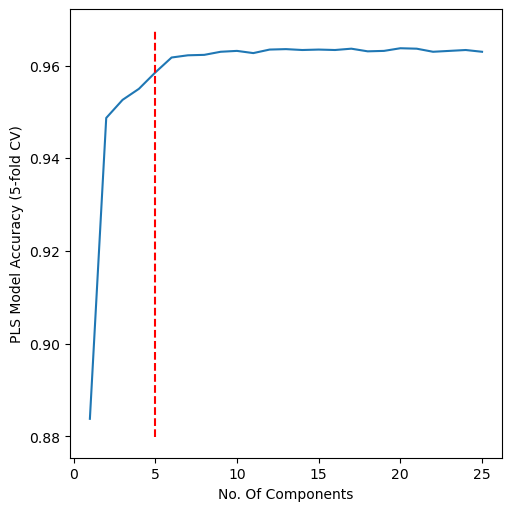

In [36]:
fig, ax = plt.subplots(figsize = (5, 5), constrained_layout = True)

n_components = pls_model.n_components
q2y = pls_model.assessment_metrics['Q2Y']['value']
q2y_pval = pls_model.assessment_metrics['Q2Y']['pval']
print('Perturbation: {} | {} components | Q2Y {:.3f} (p = {:.2E})'.format(pert, n_components, q2y, q2y_pval))


sns.lineplot(y = pls_model.metric_per_component, x = range(1, len(pls_model.metric_per_component) + 1), ax = ax)
ymin, ymax = ax.get_ylim()
ax.vlines(x = pls_model.n_components, ymin = ymin, ymax = ymax, #label = 'Selected No. of Components',
          color = 'red', linestyle = '--'
         )
ax.set_xlabel('No. Of Components')
ax.set_ylabel('PLS Model Accuracy (5-fold CV)')


## Visualize PLS Space

In [37]:
X_pls_actual = pd.DataFrame(X_pls, 
                    columns = ['PLS{}'.format(i + 1) for i in range(pls_model.n_components)])
X_pls_actual[cat_col] = tf_adata_sub.obs[cat_col].tolist()
X_pls_actual[pert_col] = tf_adata_sub.obs[pert_col].tolist()
X_pls_actual['mod_id'] = 'actual'

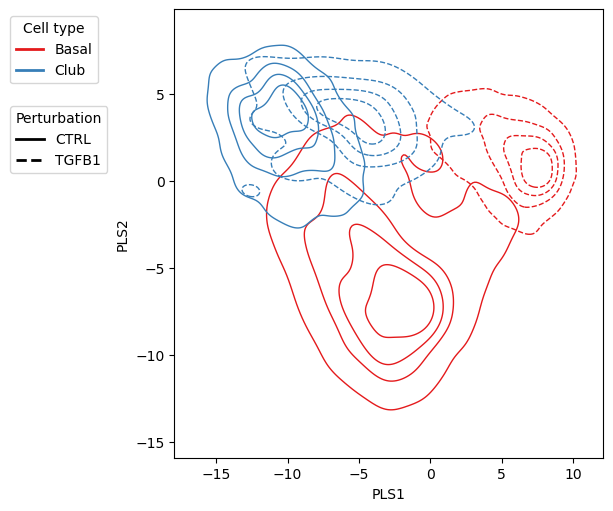

In [38]:
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout = True)

cats = sorted(X_pls_actual[cat_col].dropna().unique())
palette = dict(zip(cats, sns.color_palette('Set1', n_colors=len(cats))))
linestyle_map = {
    ctrl_pert: '-',
    pert: '--',
}

# KDE plots
for cat in cats:
    for pert in [ctrl_pert, pert]:
        df_sub = X_pls_actual[
            (X_pls_actual[cat_col] == cat) &
            (X_pls_actual[pert_col] == pert)
        ]
        
        if len(df_sub) < 5:
            continue

        sns.kdeplot(
            data=df_sub,
            x='PLS1',
            y='PLS2',
            fill=False,
            levels=5,
            thresh=0.05,
            color=palette[cat],
            linestyles=linestyle_map[pert],
            linewidths=1,
            ax=ax,
        )

ax.set_xlabel('PLS1')
ax.set_ylabel('PLS2')

# ---- Manual legend ----

# color legend (cell types)
color_handles = [
    mlines.Line2D([], [], color=palette[cat], lw=2, label=cat)
    for cat in cats
]

# linestyle legend (perturbation)
style_handles = [
    mlines.Line2D([], [], color='black', linestyle=linestyle_map[p], lw=2, label=p)
    for p in [ctrl_pert, pert]
]

legend1 = ax.legend(
    handles=color_handles,
    title='Cell type',
    bbox_to_anchor=(-0.4, 1),
    loc='upper left'
)

ax.add_artist(legend1)

ax.legend(
    handles=style_handles,
    title='Perturbation',
    bbox_to_anchor=(-0.4, 0.8),
    loc='upper left'
)


In [231]:
ed = get_euclidean_distance(adata = tf_adata_sub, use_pls = True)
cd = get_cosine_distance(adata = tf_adata_sub, use_pls = True)
cd_direction = get_convergence_label(adata = tf_adata_sub, use_pls = True)
res = {**ed, **{'cos': cd, 'pert': pert, 'direction': cd_direction}}
res

{'Multiciliated': 6.120870778130133,
 'Club': 8.44388017126186,
 'cos': 0.48568266468660526,
 'pert': 'BMP4',
 'direction': 'convergence'}

We can see that, in PLS space, the cosine distance is still strong, and the difference in euclidean distances is even stronger. 

The ultimate goals will be to:

1) Identify a subnetwork defining the perturbation response in these cell types 
2) Identify the nodes in the categorical bias that cause the discrepancies in teh perturbation shift
3) See whether we can get multiciliated cells to response in the same manner (directionaly and strength wise) as basal cells, or vice-versa. 

# Check Model Predictions

We also need a condition that the model predictions accurately predict the perturbation response differences.



In [39]:
conds_include = [ct + '^' + pert for ct in cell_types]

In [40]:
n_ensembles = 10
seed_multiplier = 21234
def load_model(fold, ensemble_idx, from_trainer = False):
    """Loads the model and training object.

    Two different ways to do so: from pickled training object (larger files) or from model state dict `.pt` file (smaller files to transfer).

    Parameters
    ----------
    fold : int
        fold split
    ensemble_idx : int
        ensemble index
    from_trainer : bool, optional
        whether to load from trainer object or model state dict, by default False
        if False, the training object is not returned
    """
    fn_base = os.path.join(data_path, 'processed', '{}_fold{}'.format(author, fold))
    if from_trainer:
        if ensemble_idx <= 3:
            fn_trainer =  os.path.join(fn_base + 'trainer_actual_ensemble{}.pickle'.format(ensemble_idx))
        else:
            fn_trainer = os.path.join(fn_base + 'trainer_actual.pickle')


        trainer = io.read_pickled_object(fn_trainer)
        mod = trainer.mod
    else:
        seed_ = seed + ensemble_idx + 1 + (seed_multiplier * ensemble_idx * fold) if ensemble_idx <= 3 else seed
        mod, trainer = initialize_mod_and_trainer(
            fold = fold, 
            adversarial_penalty = True, 
            randomize = False, 
            seed = seed_
        )
        
        if ensemble_idx < n_ensembles - 1: # +1 of the originally trained model
            fn_mod = os.path.join(fn_base + 'model_actual_ensemble{}.pt'.format(ensemble_idx))
        else:
            fn_mod = os.path.join(fn_base + 'model_actual.pt')
            
        mod.load_state_dict(torch.load(fn_mod))
        trainer = None
    return mod, trainer
        

## Test OOD predictions

In [41]:
conda_fold_map = defaultdict(list)
for fold in range(5):
    split = get_split(author = author, fold = fold)

    for ci in conds_include:
        if ci in split['test_conds']:
            conda_fold_map[ci].append(fold)

for ci, fold in conda_fold_map.items():
    assert len(fold) == 1, 'Need to deal with scenarios where not present or present in multiple folds'
    conda_fold_map[ci] = fold[0]

In [42]:
X_pls_pred = []
for test_cond, fold in conda_fold_map.items():  
    split = get_split(author = author, fold = fold)

    train_barcodes = split['train_barcodes']
    test_barcodes = split['test_barcodes']
    
    # ------------ specify condition-specific counterfactual ------------
    ct = test_cond.split('^')[0]
    ctrl_cond = ct + '^' + ctrl_pert

    condition_subset = [ctrl_cond, test_cond]
    #     condition_mask = tf_adata.obs.condition.isin(condition_subset)

    train_cond_mask = tf_adata[train_barcodes, :].obs.condition.isin(condition_subset)
    test_cond_mask = tf_adata[test_barcodes, :].obs.condition.isin(condition_subset)
    train_barcodes = train_cond_mask[train_cond_mask].index.tolist()
    test_barcodes = test_cond_mask[test_cond_mask].index.tolist()
    
    #for ensemble_idx in trange(n_ensembles): # ITERATING
    ensemble_idx = n_ensembles - 1
    
    mod, _ = load_model(fold = fold, ensemble_idx = ensemble_idx, from_trainer = False)
    
    with suppress_all_output():
        tf_adata_predicted = get_prediction(
            mod = mod,
            train_cells = train_barcodes,
            test_cells = test_barcodes, 
            tf_adata = tf_adata,
            cat_col = cat_col,
            pert_col = pert_col,
            ctrl_pert = ctrl_pert, 
            counterfactual = 'perturbation', # counterfactual from tests
            cat_counterfactual_map = None,
            remove_type = 'none',
            return_bias = False, 
            max_cells = int(5e3), 
            return_full = False, 
            stim_label_map = None, # special use case for Kang
        )
        
    X_pls_ = pd.DataFrame(
        pls_model.transform(tf_adata_predicted.X), 
        columns = ['PLS{}'.format(i+1) for i in range(pls_model.n_components)]
    )
    X_pls_[cat_col] = ct
    X_pls_[pert_col] = pert
    X_pls_['mod_id'] = 'fold{}_ensemble{}'.format(fold, ensemble_idx)
    
    X_pls_pred.append(X_pls_) 

X_pls_pred = pd.concat(X_pls_pred) 
# # for visualization copy the actual control data
X_pls_pred = pd.concat([
    X_pls_pred, 
    X_pls_actual[X_pls_actual[pert_col] == ctrl_pert].copy()
])

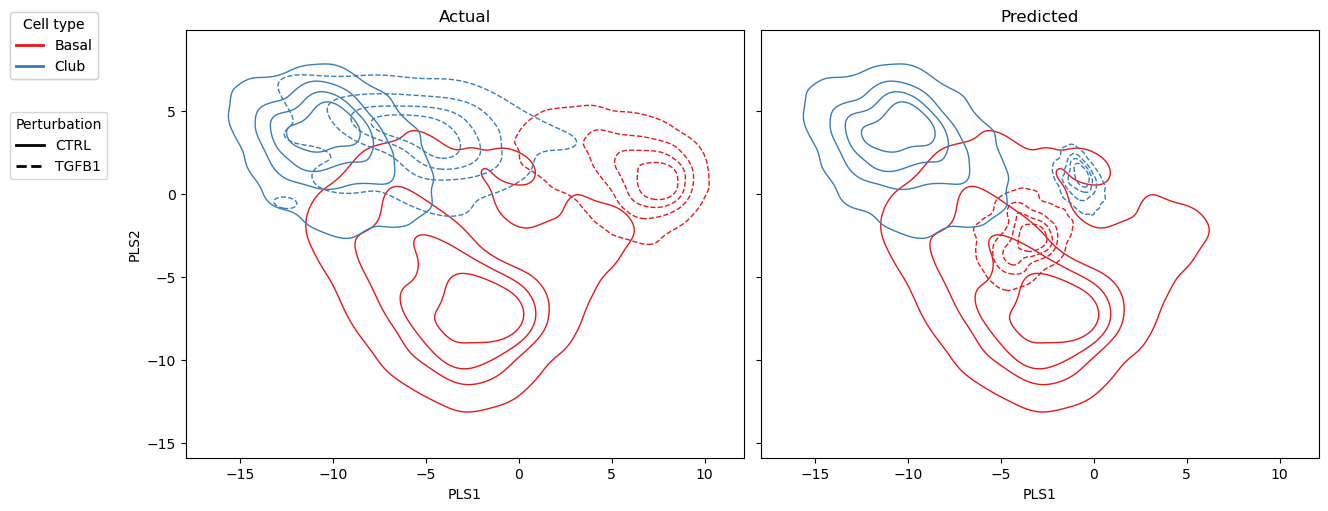

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True, constrained_layout=True)

cats = sorted(X_pls_actual[cat_col].dropna().unique())
palette = dict(zip(cats, sns.color_palette('Set1', n_colors=len(cats))))
linestyle_map = {
    ctrl_pert: '-',
    pert: '--',
}

for ax, X_pls, title in zip(axes, [X_pls_actual, X_pls_pred], ['Actual', 'Predicted']):
    
    for cat in cats:
        for pert in [ctrl_pert, pert]:
            df_sub = X_pls[
                (X_pls[cat_col] == cat) &
                (X_pls[pert_col] == pert)
            ]
            
            if len(df_sub) < 5:
                continue

            sns.kdeplot(
                data=df_sub,
                x='PLS1',
                y='PLS2',
                fill=False,
                levels=5,
                thresh=0.05,
                color=palette[cat],
                linestyles=linestyle_map[pert],
                linewidths=1,
                ax=ax,
            )
    
    ax.set_title(title)
    ax.set_xlabel('PLS1')

axes[0].set_ylabel('PLS2')
axes[1].set_ylabel('')

# ---- Manual legend ----

# color legend (cell types)
color_handles = [
    mlines.Line2D([], [], color=palette[cat], lw=2, label=cat)
    for cat in cats
]

# linestyle legend (perturbation)
style_handles = [
    mlines.Line2D([], [], color='black', linestyle=linestyle_map[p], lw=2, label=p)
    for p in [ctrl_pert, pert]
]

legend1 = fig.legend(
    handles=color_handles,
    title='Cell type',
    bbox_to_anchor=(-0.1, 1),
    loc='upper left'
)

fig.add_artist(legend1)

fig.legend(
    handles=style_handles,
    title='Perturbation',
    bbox_to_anchor=(-0.1, 0.8),  
    loc='upper left'
)

## Train Predictions

In [44]:
cond_fold_map = []
for fold in range(5):
    split = get_split(author = author, fold = fold)
    if len(set(conds_include).difference(split['train_conds'])) == 0:
        cond_fold_map.append(fold)

In [45]:

X_pls_pred = []

for fold in cond_fold_map:
    split = get_split(author = author, fold = fold)

    train_barcodes = split['train_barcodes']
    #ctrl_conds = [tc.split('^')[0] + '^' + ctrl_pert for tc in conds_include]

    condition_subset = conds_include # ctrl_conds 

    train_cond_mask = tf_adata[train_barcodes, :].obs.condition.isin(condition_subset)
    train_barcodes = train_cond_mask[train_cond_mask].index.tolist()


    #for ensemble_idx in trange(n_ensembles): # ITERATING
    ensemble_idx = n_ensembles - 1

    mod, _ = load_model(fold = fold, ensemble_idx = ensemble_idx, from_trainer = False)

    with suppress_all_output():
        tf_adata_predicted = get_prediction(
            mod = mod,
            train_cells = train_barcodes,
            test_cells = [], 
            tf_adata = tf_adata,
            cat_col = cat_col,
            pert_col = pert_col,
            ctrl_pert = ctrl_pert, 
            counterfactual = None, # counterfactual from tests
            cat_counterfactual_map = None,
            remove_type = 'none',
            return_bias = False, 
            max_cells = int(5e3), 
            return_full = False, 
            stim_label_map = None, # special use case for Kang
        )

    X_pls_ = pd.DataFrame(
        pls_model.transform(tf_adata_predicted.X), 
        columns = ['PLS{}'.format(i+1) for i in range(pls_model.n_components)]
    )
    X_pls_[cat_col] = tf_adata_predicted.obs[cat_col].values
    X_pls_[pert_col] = tf_adata_predicted.obs[pert_col].values
    X_pls_['mod_id'] = 'fold{}_ensemble{}'.format(fold, ensemble_idx)
    
    # # for visualization copy the actual control data
    X_pls_ = pd.concat([
        X_pls_, 
        X_pls_actual[X_pls_actual[pert_col] == ctrl_pert].copy()
    ])
    
    
    
    X_pls_pred.append(X_pls_) 

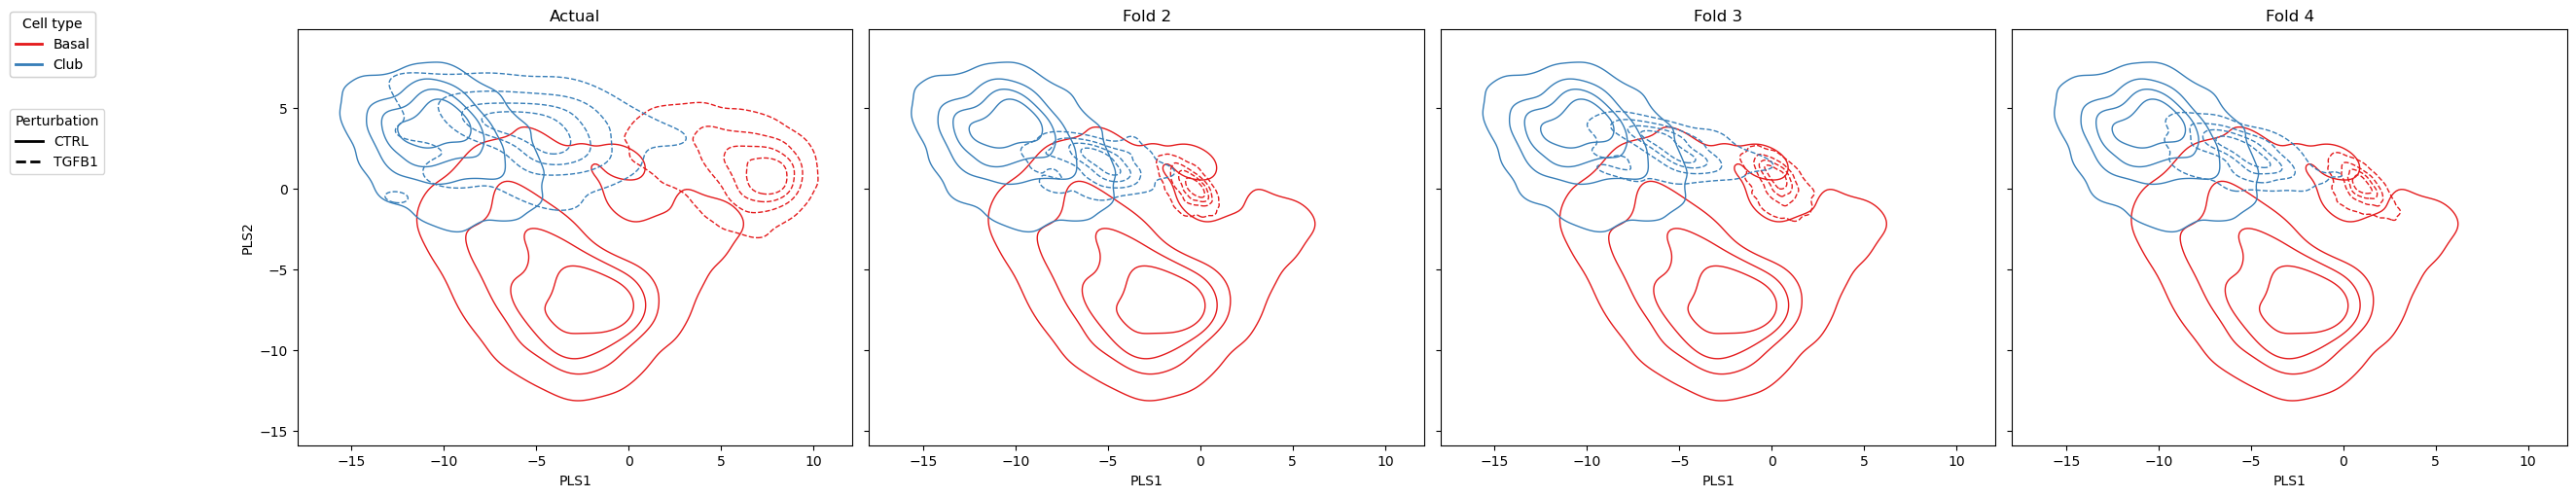

In [46]:
n_pred = len(X_pls_pred)
n_panels = 1 + n_pred

fig, axes = plt.subplots(
    1, n_panels,
    figsize=(6 * n_panels, 5),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

if n_panels == 1:
    axes = [axes]

cats = sorted(X_pls_actual[cat_col].dropna().unique())
palette = dict(zip(cats, sns.color_palette('Set1', n_colors=len(cats))))
linestyle_map = {
    ctrl_pert: '-',
    pert: '--',
}

all_dfs = [X_pls_actual] + X_pls_pred
titles = ['Actual'] + ['Fold {}'.format(i + 1) for i in cond_fold_map]

for i, (ax, X_pls, title) in enumerate(zip(axes, all_dfs, titles)):

    for cat in cats:
        for p in [ctrl_pert, pert]:
            df_sub = X_pls[
                (X_pls[cat_col] == cat) &
                (X_pls[pert_col] == p)
            ]

            if len(df_sub) < 5:
                continue

            sns.kdeplot(
                data=df_sub,
                x='PLS1',
                y='PLS2',
                fill=False,
                levels=5,
                thresh=0.05,
                color=palette[cat],
                linestyles=linestyle_map[p],
                linewidths=1,
                ax=ax,
            )

    ax.set_title(title)
    ax.set_xlabel('PLS1')
    ax.set_ylabel('PLS2' if i == 0 else '')

# ---- Manual legend ----

color_handles = [
    mlines.Line2D([], [], color=palette[cat], lw=2, label=cat)
    for cat in cats
]

style_handles = [
    mlines.Line2D([], [], color='black', linestyle=linestyle_map[p], lw=2, label=p)
    for p in [ctrl_pert, pert]
]

legend1 = fig.legend(
    handles=color_handles,
    title='Cell type',
    bbox_to_anchor=(-0.1, 1),
    loc='upper left'
)

fig.add_artist(legend1)

fig.legend(
    handles=style_handles,
    title='Perturbation',
    bbox_to_anchor=(-0.1, 0.8),
    loc='upper left'
)